# Machine Learning-Based Prediction of University Student Dropout

**Pathway:** Classification (binary: Dropout vs. Graduate)

**Dataset:** UCI "Predict Students' Dropout and Academic Success" (Realinho et al., 2021),
Instituto Politecnico de Portalegre, Portugal. CC BY 4.0. Retained as Portuguese data
throughout this notebook (not renamed/relabelled as local data) — see the note in the
"Load the Dataset" section for how country-specific features are handled honestly.

**Goal:** predict whether a student will drop out using information available early in
their academic path (enrollment demographics, socio-economic indicators, and 1st/2nd
semester academic performance), so an institution could flag at-risk students for
support before they withdraw.


## Team Contribution — Sadiya Mohon Auti (Lead Technical Contribution)

Based on the project's contribution statement, **Sadiya Mohon Auti** handled several of the core technical stages of the project, including:

1. **EDA (Part 2):** 2nd-semester approved-units analysis, correlation heatmap/multicollinearity check, and outlier analysis for Age and Admission Grade.
2. **Preprocessing (Part 2):** construction of the numeric/categorical preprocessing pipeline and leakage-safe `fit_transform()` / `transform()` workflow.
3. **Model Development (Part 2):** Random Forest and Gradient Boosting, including untuned and tuned versions and their `GridSearchCV` hyperparameter searches.
4. **Evaluation & Interpretation (Part 2):** feature-importance interpretation for Logistic Regression, Random Forest, and Gradient Boosting; error analysis; final model selection; threshold sensitivity; cross-validation uncertainty; and final model saving.
5. **Reproducibility:** the updated notebook explicitly documents the 70/15/15 train-validation-test design and keeps the test set untouched until final evaluation.

**Important:** this contribution section reflects the existing project contribution statement; it does not invent new work or claim that another member did no work.


## Step 0 — Imports and Global Settings

In [1]:
# Core data handling
import pandas as pd
import numpy as np
import joblib   # used later to persist the final selected model as a reusable artifact
import os
import json

# Modeling utilities
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

import time
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics and diagnostic plots
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Fixed once and reused everywhere a random process occurs (train/test split,
# cross-validation folds, and every stochastic model) so the whole workflow is
# reproducible end to end (Section 11 requirement).
RANDOM_SEED = 42

print("All necessary packages imported")


# Create output directory for saved figures.
os.makedirs("figures", exist_ok=True)


All necessary packages imported


## Step 1 — Load the Dataset (UCI "Predict Students' Dropout and Academic Success")

Source: https://archive.ics.uci.edu/dataset/697/ — CC BY 4.0.
Citation: Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021).
Predict Students' Dropout and Academic Success [Dataset]. UCI ML Repository.
https://doi.org/10.24432/C5MC89

**Country-context note:** this dataset comes from a Portuguese institution. We keep it
labelled as such throughout (no relabelling as local data). Where a feature has no
defensible equivalent outside that context (e.g. Portugal's national macroeconomic
indicators), it is dropped and the reason is documented at the point it's dropped,
rather than silently omitted. Where a feature does map conceptually to a Bangladeshi
higher-education context (financial standing, parental education, relocation/displacement,
academic performance), it is kept and interpreted that way in the analysis and report.


In [2]:
# The file is semicolon-delimited, not comma-delimited — confirmed by inspection,
# not assumed. Using the default comma separator here would silently load the whole
# file as a single garbage column.
df = pd.read_csv("data.csv", sep=";")
print("Dataset loaded successfully")


Dataset loaded successfully


In [3]:
# Initial look BEFORE any cleaning — establishes the raw shape, dtypes, and
# column-name formatting we're starting from.
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
# Some column names carry stray whitespace/tab characters (e.g. a trailing "\t"
# on "Daytime/evening attendance"). Left uncleaned, this would silently break any
# later code that references a column by its exact name. This is itself a small
# data-quality finding worth naming in the data-audit section of the report.
df.columns = df.columns.str.strip()
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Step 2 — Data Audit (DW-3)

Checks performed here: duplicate rows, missing values, and near-constant features.
Nothing is dropped in this section — this section only produces the *evidence* that
later justifies what gets dropped in Feature Selection.


In [5]:
# Duplicate rows and missing values are DOCUMENTED as absent by the dataset's own
# metadata, but that is verified here rather than trusted blindly.
n_dupes = df.duplicated().sum()
print("Number of duplicate rows:", n_dupes)

null_counts = df.isnull().sum()
columns_missing = null_counts[null_counts > 0]
print("Number of missing values per column:\n", columns_missing)

# ------------------------------------------------------------------------
# Near-constant feature check — this is the EVIDENCE for dropping
# Nacionality/International in the Feature Selection step below. Without this
# check being visible in the notebook, that drop would look like an
# unjustified/arbitrary choice in the viva rather than an audit-driven one.
# ------------------------------------------------------------------------
print("\nNacionality — top value share:")
print(df["Nacionality"].value_counts(normalize=True).head(1))

print("\nInternational — top value share:")
print(df["International"].value_counts(normalize=True).head(1))


Number of duplicate rows: 0
Number of missing values per column:
 Series([], dtype: int64)

Nacionality — top value share:
Nacionality
1    0.975136
Name: proportion, dtype: float64

International — top value share:
International
0    0.975136
Name: proportion, dtype: float64


## Step 3 — Target Definition (DW-1)

**Design decision:** the raw `Target` column has three classes — Dropout, Enrolled,
Graduate. "Enrolled" students have an unresolved outcome (still studying) rather than
a terminal one, so mixing it in as a third class would blur the real prediction
question ("who is at risk of dropping out"). We collapse this to a **binary**
classification problem — Dropout vs. Graduate — and this decision is stated explicitly
here (and must be repeated in the report) rather than silently dropping rows.


In [6]:
# Remove unresolved "Enrolled" outcomes, then map the remaining classes:
# 1 = Dropout (positive/at-risk), 0 = Graduate.
df = df[df["Target"] != "Enrolled"].copy()
df["Target"] = df["Target"].map({"Dropout": 1, "Graduate": 0})
print("Binary target distribution:")
print(df["Target"].value_counts())


Binary target distribution:
Target
0    2209
1    1421
Name: count, dtype: int64


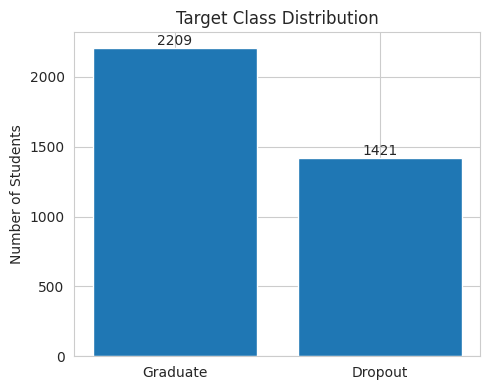

Dropout rate: 39.1%


In [7]:
# Outcome distribution.
target_counts = df["Target"].map({0: "Graduate", 1: "Dropout"}).value_counts()
plt.figure(figsize=(5, 4))
plt.bar(target_counts.index, target_counts.values)
plt.title("Target Class Distribution")
plt.ylabel("Number of Students")
plt.xlabel("")
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
plt.savefig("eda_target_distribution.png", dpi=150)
plt.show()
print(f"Dropout rate: {df['Target'].mean():.1%}")


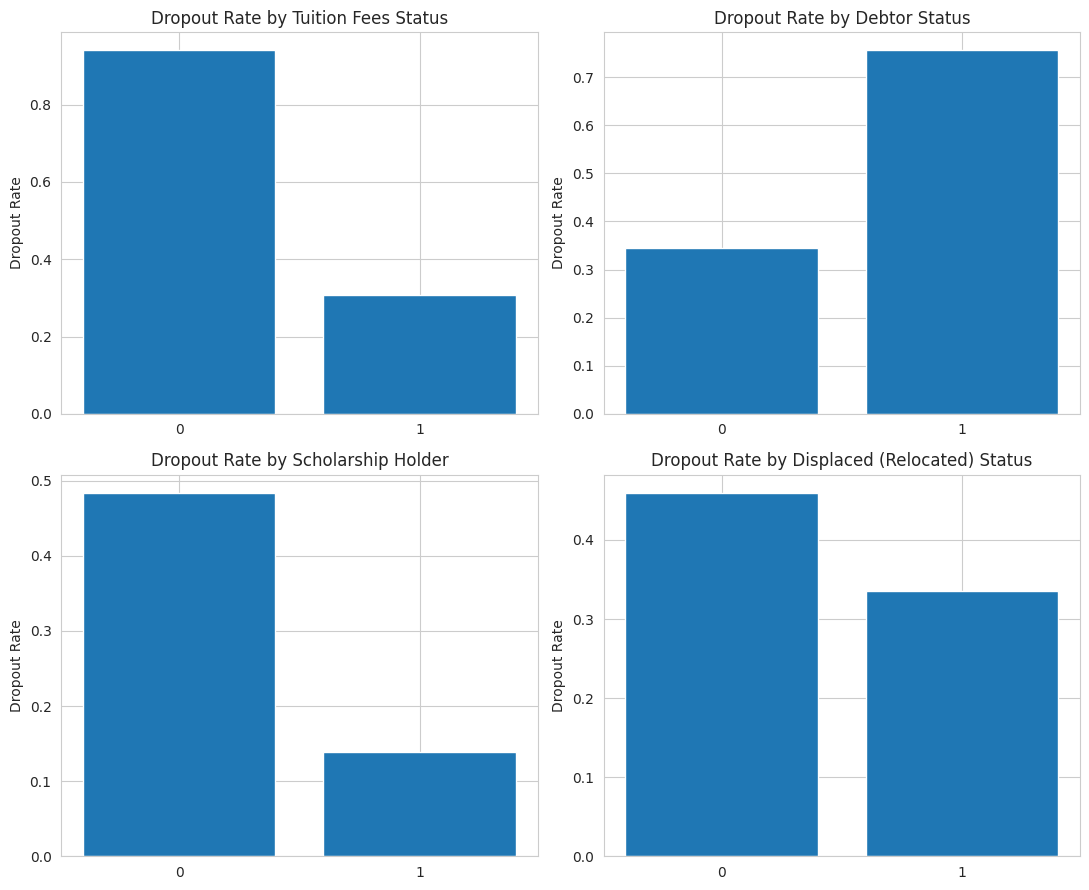

In [8]:
# Dropout rate by financially/socially-linked indicators.
cat_relationships = [
    ("Tuition fees up to date", "Tuition Fees Status"),
    ("Debtor", "Debtor Status"),
    ("Scholarship holder", "Scholarship Holder"),
    ("Displaced", "Displaced (Relocated) Status"),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (col, title) in zip(axes.flat, cat_relationships):
    rate = df.groupby(col)["Target"].mean()
    ax.bar([str(x) for x in rate.index], rate.values)
    ax.set_title(f"Dropout Rate by {title}")
    ax.set_ylabel("Dropout Rate")
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("eda_categorical_relationships.png", dpi=150)
plt.show()


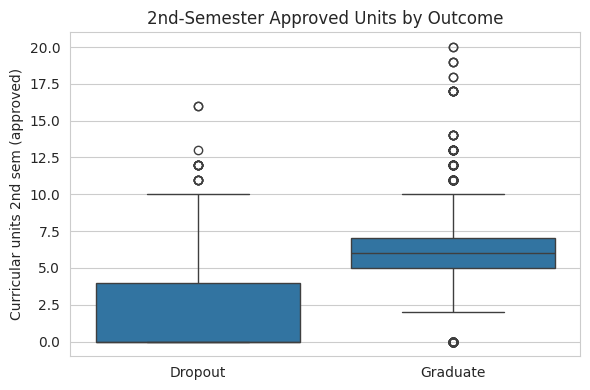

In [9]:
# 2nd-semester approved units is expected to be the single most direct signal of
# in-progress academic standing — this plot checks whether Dropout/Graduate groups
# actually separate on it, which is useful evidence when interpreting model results
# later (DW-10).
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df, x=df["Target"].map({0: "Graduate", 1: "Dropout"}),
    y="Curricular units 2nd sem (approved)"
)
plt.title("2nd-Semester Approved Units by Outcome")
plt.xlabel("")
plt.tight_layout()
plt.savefig("eda_approved_units_boxplot.png", dpi=150)
plt.show()


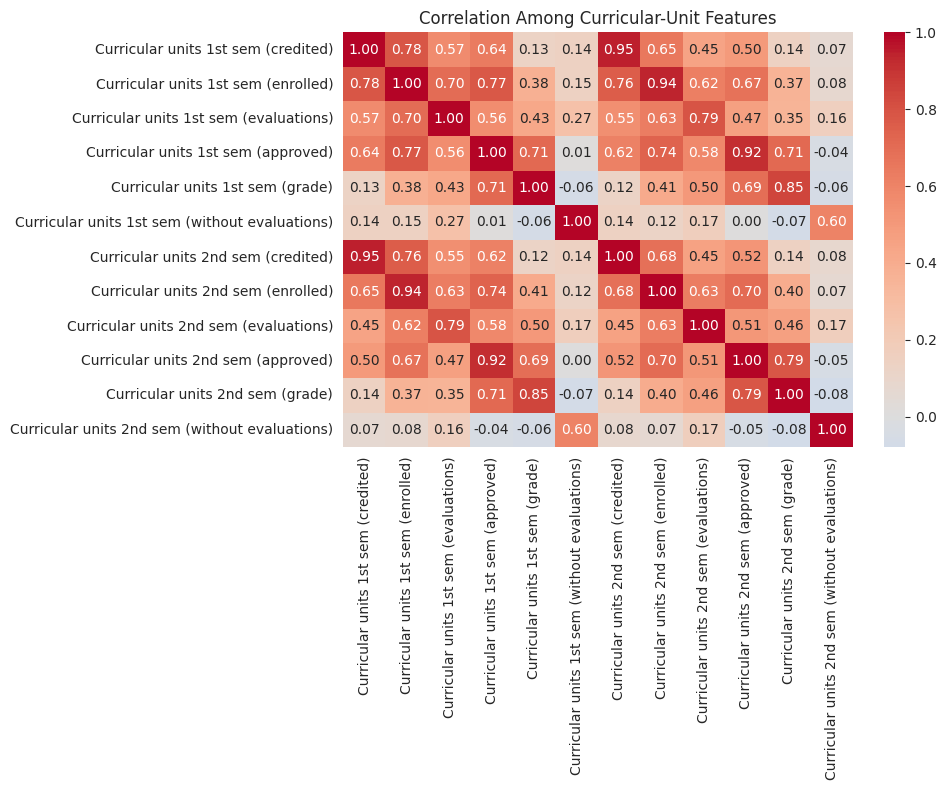

In [10]:
# Curricular-unit columns are structurally related by definition
# (approved <= evaluations <= enrolled, for each semester), so high correlation
# here is expected. This plot is what JUSTIFIES flagging multicollinearity as an
# interpretation caveat for the Logistic Regression coefficients later
# (Section 6 requires checking linear-model assumptions).
curricular_cols = [c for c in df.columns if "Curricular units" in c]
plt.figure(figsize=(10, 8))
sns.heatmap(df[curricular_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Among Curricular-Unit Features")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150)
plt.show()


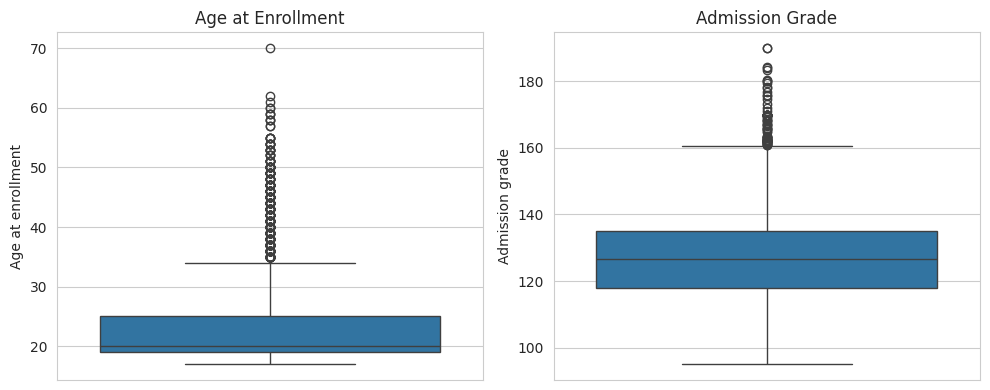

Age range: 17-70
Admission grade range: 95.0-190.0


In [11]:
# Age at enrollment and Admission grade are the two numeric fields most likely to
# show genuine outliers. We only VISUALLY CHECK them here — no capping or removal
# is applied without a documented rule, per the Data Requirements table's caution
# against undocumented manual edits. Wide spreads here (older/mature students,
# varied program admission cutoffs) are expected to be legitimate, not data errors.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df["Age at enrollment"], ax=axes[0])
axes[0].set_title("Age at Enrollment")
sns.boxplot(y=df["Admission grade"], ax=axes[1])
axes[1].set_title("Admission Grade")
plt.tight_layout()
plt.savefig("eda_outlier_check.png", dpi=150)
plt.show()

print(f"Age range: {df['Age at enrollment'].min()}-{df['Age at enrollment'].max()}")
print(f"Admission grade range: {df['Admission grade'].min()}-{df['Admission grade'].max()}")


## Step 5 — Feature Selection (DW-6 prep)

Two groups of columns are dropped here, each for a distinct, documented reason —
neither is a silent omission:

- **Nacionality, International** — the audit above (Step 2) showed these are
  near-constant (~97.5% one value each), carrying almost no discriminative signal.
- **Unemployment rate, Inflation rate, GDP** — these are Portugal's own national
  macroeconomic indicators at time of enrollment. Keeping them would implicitly
  encode "which year/economic climate in Portugal", which has no transferable
  meaning in a Bangladeshi-context discussion and risks the model leaning on a
  signal that doesn't generalize. This is recorded as a limitation, not hidden.


In [12]:
drop_cols = ["Nacionality", "International", "Unemployment rate", "Inflation rate", "GDP"]
df = df.drop(columns=drop_cols)

print(df.columns.tolist())
print("New Shape:", df.shape)


['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Target']
New Shape: (3630, 32)


## Step 6 — Derived Feature: Discipline_Group (DW-6 feature engineering)

`Course` contains 17 sparse Portuguese program codes (some with fewer than 20
students), which is opaque to a non-Portuguese reader and would fragment one-hot
encoding into many rarely-populated columns. We group these into six broader
discipline clusters — similar to how faculties are organized in the Bangladeshi
university system — for two reasons: (1) reduces cardinality/sparsity before
encoding, and (2) makes EDA/interpretation legible without needing the Portuguese
course-code lookup table. The original `Course` values and names are still kept
in the project's data dictionary for provenance/citation.


In [13]:
# Mapping built from the UCI variable documentation's official course-code list.
course_to_group = {
    9500: "Health Sciences", 9085: "Health Sciences", 9556: "Health Sciences",
    9147: "Business & Management", 9991: "Business & Management",
    9254: "Business & Management", 9670: "Business & Management",
    171: "Design, Media & Communication", 9070: "Design, Media & Communication",
    9773: "Design, Media & Communication",
    9238: "Social Sciences & Education", 8014: "Social Sciences & Education",
    9853: "Social Sciences & Education",
    9119: "Engineering & Applied Sciences", 33: "Engineering & Applied Sciences",
    9003: "Agriculture & Life Sciences", 9130: "Agriculture & Life Sciences",
}
df["Discipline_Group"] = df["Course"].map(course_to_group)

# Defensive check: if any course code doesn't appear in the mapping above,
# it would silently become NaN and break the pipeline downstream — this makes
# that failure visible immediately instead of surfacing as a confusing error
# later in preprocessing.
missing_count = df["Discipline_Group"].isnull().sum()
if missing_count > 0:
    print("Warning: Unmapped course codes found!")
    print("Number of unmapped codes:", missing_count)
else:
    print("All course codes mapped successfully!")

# Raw Course is dropped from the modeling feature set now that Discipline_Group
# replaces it — it remains documented (with its original codes/names) in the
# project's data dictionary file, not in the modeling data.
df = df.drop(columns=["Course"])


All course codes mapped successfully!


## Step 7 — Stratified Train / Validation / Test Split (DW-5)

A **70% / 15% / 15% stratified split** is used as required for this updated project.

- **70% Training set:** used to fit preprocessing, train models, and perform 5-fold cross-validation for hyperparameter tuning.
- **15% Validation set:** used only for model comparison, threshold/error analysis during development, and selecting the final model.
- **15% Test set:** kept completely untouched until the final evaluation of the selected model.
- **Why stratified:** the target is imbalanced, so stratification preserves a similar Dropout/Graduate ratio in all three sets.
- **Why split before preprocessing:** no imputation, scaling, or encoding statistics are learned from validation or test data. This directly follows the FR-2 leakage-control requirement.

This separation makes the workflow easier to defend in the viva: **train = learning/tuning, validation = selection, test = final evidence.**


In [14]:
X = df.drop(columns=["Target"])
y = df["Target"]

# First hold out 30% for validation + test.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_SEED
)

# Split the remaining 30% equally into validation and test.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED
)

print("70/15/15 stratified split completed")
print(f"Train:      {X_train.shape[0]} rows ({len(X_train)/len(X):.1%})")
print(f"Validation: {X_val.shape[0]} rows ({len(X_val)/len(X):.1%})")
print(f"Test:       {X_test.shape[0]} rows ({len(X_test)/len(X):.1%})")
print(f"Dropout rate - Train: {y_train.mean():.3f}")
print(f"Dropout rate - Val:   {y_val.mean():.3f}")
print(f"Dropout rate - Test:  {y_test.mean():.3f}")


70/15/15 stratified split completed
Train:      2541 rows (70.0%)
Validation: 544 rows (15.0%)
Test:       545 rows (15.0%)
Dropout rate - Train: 0.392
Dropout rate - Val:   0.392
Dropout rate - Test:  0.391


## Step 8 — Defining Column Groups for Preprocessing

Numeric and categorical features are handled separately because they need
different transformations:
- **Numeric** (grades, counts, age) need scaling for distance-/gradient-based
  models (KNN, SVM-style, Logistic Regression).
- **Categorical-coded** features are nominal, not ordinal — their integer codes
  carry no meaningful order, so they need encoding, not scaling.


In [15]:
numeric_features = [
    "Application order", "Previous qualification (grade)", "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)", "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)", "Curricular units 2nd sem (without evaluations)",
]

categorical_features = [
    "Marital status", "Application mode", "Daytime/evening attendance",
    "Previous qualification", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced",
    "Educational special needs", "Debtor", "Tuition fees up to date",
    "Gender", "Scholarship holder", "Discipline_Group",
]

# Sanity check: every remaining column in X_train must be accounted for exactly
# once. Catches a column being silently forgotten (and therefore silently
# dropped from the model) if the feature set ever changes upstream.
all_cols = set(X_train.columns)
numeric_cols = set(numeric_features)
categoric_cols = set(categorical_features)

remaining = all_cols - numeric_cols - categoric_cols

if remaining:
    print(f"Unassigned columns found: {list(remaining)}")
    print(f"Total: {len(remaining)} column(s)")
else:
    print("All columns properly classified!")


All columns properly classified!


In [16]:
# Final sanity check on the full engineered dataset (post feature-selection,
# post Discipline_Group, pre-split-application) — confirms dtypes/shape look
# right before the preprocessing pipeline is built and fit.
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 3630 entries, 0 to 4423
Data columns (total 32 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3630 non-null   int64  
 1   Application mode                                3630 non-null   int64  
 2   Application order                               3630 non-null   int64  
 3   Daytime/evening attendance                      3630 non-null   int64  
 4   Previous qualification                          3630 non-null   int64  
 5   Previous qualification (grade)                  3630 non-null   float64
 6   Mother's qualification                          3630 non-null   int64  
 7   Father's qualification                          3630 non-null   int64  
 8   Mother's occupation                             3630 non-null   int64  
 9   Father's occupation                           

,Marital status,Application mode,Application order,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,...,Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Target,Discipline_Group
0,1,17,5,1,1,122.0,19,12,5,9,...,0.000000,0,0,0,0,0,0.000000,0,1,"Design, Media & Communication"
1,1,15,1,1,1,160.0,1,3,3,3,...,14.000000,0,0,6,6,6,13.666667,0,0,Business & Management
2,1,1,5,1,1,122.0,37,37,9,9,...,0.000000,0,0,6,0,0,0.000000,0,1,"Design, Media & Communication"
3,1,17,2,1,1,122.0,38,37,5,3,...,13.428571,0,0,6,10,5,12.400000,0,0,"Design, Media & Communication"
4,2,39,1,0,1,100.0,37,38,9,9,...,12.333333,0,0,6,6,6,13.000000,0,0,Social Sciences & Education


## Step 9 — Preprocessing Pipeline (DW-6)

- **SimpleImputer**, even though the audit found no missing values: a defensive
  default so the pipeline doesn't silently break if the data source ever changes
  slightly on a re-run — cheap insurance, easy to defend in a viva.
- **StandardScaler** on numeric features: puts features like Age (range ~17-70)
  and Admission grade (range 0-200) on a comparable scale — needed for
  distance-/gradient-based models, and included for every model (even
  tree-based ones that don't strictly need it) so all models are compared on
  an identical, fair preprocessing pipeline (Section 8 "fair comparison" rule).
- **OneHotEncoder(handle_unknown="ignore")** on categorical features: these are
  nominal codes, not ordinal — encoding them as raw numbers would falsely imply
  order/distance between categories. `handle_unknown="ignore"` prevents a crash
  if the test set contains a category value unseen during training (a
  legitimate edge case, not leakage).


In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


## Step 10 — Fit Preprocessing on Training Data Only (Leakage Control, FR-2)

`fit_transform()` is applied only to **X_train**. The validation and test sets are never used to learn scaling, imputation, or category information.

For the actual models, the same logic is implemented inside each `Pipeline`, so every model learns preprocessing only from its training folds during cross-validation and from `X_train` when fitted finally.

The validation set is used for model selection, while the test set remains untouched until the final selected-model evaluation.


In [18]:
# Demonstration of the leakage-safe preprocessing rule.
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Train shape: {X_train_processed.shape}")
print(f"Validation shape: {X_val_processed.shape}")
print(f"Test shape: {X_test_processed.shape}")
print(f"Train dropout rate: {y_train.mean():.3f}")
print(f"Validation dropout rate: {y_val.mean():.3f}")
print(f"Test dropout rate: {y_test.mean():.3f}")


Train shape: (2541, 188)
Validation shape: (544, 188)
Test shape: (545, 188)
Train dropout rate: 0.392
Validation dropout rate: 0.392
Test dropout rate: 0.391


## Step 11 — Cross-Validation Setup and Shared Validation Evaluation

Every candidate model is trained using the same **5-fold StratifiedKFold** setup on the 70% training set. Hyperparameters are selected only from training folds.

The fitted candidates are then evaluated on the separate **15% validation set**. These validation results are used for model comparison and final model selection.

The **15% test set is not used here**. It remains untouched until the selected model is frozen and evaluated once at the end.


In [19]:
# StratifiedKFold keeps the Dropout/Graduate ratio inside every training CV fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Validation results are used for model selection.
validation_results = {}

def evaluate_validation(name, fitted_pipeline, X_validation, y_validation, train_time):
    """Evaluate a fitted candidate on the validation set.
    Validation metrics may be used for model selection; the test set is not touched here.
    """
    y_pred = fitted_pipeline.predict(X_validation)
    y_proba = fitted_pipeline.predict_proba(X_validation)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_validation, y_pred),
        "Precision": precision_score(y_validation, y_pred, zero_division=0),
        "Recall": recall_score(y_validation, y_pred, zero_division=0),
        "F1": f1_score(y_validation, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_validation, y_proba),
        "Train time (s)": round(train_time, 3),
    }
    validation_results[name] = metrics

    print(f"\n=== VALIDATION: {name} ===")
    print(confusion_matrix(y_validation, y_pred))
    print(classification_report(
        y_validation, y_pred,
        target_names=["Graduate", "Dropout"],
        zero_division=0
    ))
    return metrics

print("Training/CV and validation evaluation setup completed.")


Training/CV and validation evaluation setup completed.


## Step 12 — Baseline: DummyClassifier (DW-7)

Predicts the majority class (Graduate) every time. This sets the floor every
real model must beat — without it, a high accuracy number has no reference
point to be judged against.


In [20]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)),
])

t0 = time.time()
baseline_pipeline.fit(X_train, y_train)
baseline_time = time.time() - t0

# Note: DummyClassifier's predict_proba is degenerate (always one class with
# probability 1), so its ROC-AUC will show as 0.5 (chance level) — expected
# behavior for a majority-class baseline, not a bug.
evaluate_validation("Baseline (Majority Class)", baseline_pipeline, X_val, y_val, baseline_time)



=== VALIDATION: Baseline (Majority Class) ===
[[331   0]
 [213   0]]
              precision    recall  f1-score   support

    Graduate       0.61      1.00      0.76       331
     Dropout       0.00      0.00      0.00       213

    accuracy                           0.61       544
   macro avg       0.30      0.50      0.38       544
weighted avg       0.37      0.61      0.46       544



{'Accuracy': 0.6084558823529411,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC-AUC': np.float64(0.5),
 'Train time (s)': 0.051}

## Step 13 — Logistic Regression (DW-8)

Interpretable linear baseline model. Binary target, ~3,600 rows, moderate
dimensionality after encoding — comfortably within logistic regression's
range without needing anything more complex to get a reasonable signal.
Coefficients directly answer "what drives dropout", which matters for the
interpretation section (DW-10) and viva defense.


### Untuned

In [21]:
lr_untuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])

t0 = time.time()
lr_untuned_pipeline.fit(X_train, y_train)
lr_untuned_time = time.time() - t0

print("\n" + "="*60)
print("UNTUNED LOGISTIC REGRESSION RESULTS")
print("="*60)
evaluate_validation("Logistic Regression (Untuned)", lr_untuned_pipeline, X_val, y_val, lr_untuned_time)



UNTUNED LOGISTIC REGRESSION RESULTS

=== VALIDATION: Logistic Regression (Untuned) ===
[[312  19]
 [ 20 193]]
              precision    recall  f1-score   support

    Graduate       0.94      0.94      0.94       331
     Dropout       0.91      0.91      0.91       213

    accuracy                           0.93       544
   macro avg       0.93      0.92      0.92       544
weighted avg       0.93      0.93      0.93       544



{'Accuracy': 0.9283088235294118,
 'Precision': 0.910377358490566,
 'Recall': 0.9061032863849765,
 'F1': 0.908235294117647,
 'ROC-AUC': np.float64(0.9682283023417443),
 'Train time (s)': 0.097}

### Tuned

In [22]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])

# C controls regularization strength (smaller = stronger regularization) — searched
# on a log scale since its effect is multiplicative, not additive. l1 vs l2 penalty
# compared to see whether automatic feature sparsity (l1) helps given the many
# one-hot columns. 'liblinear' supports both penalties for binary classification.
lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"],
}

# scoring="f1": with class imbalance, accuracy would reward a model that mostly
# predicts the majority class; F1 balances precision/recall on the Dropout
# (positive) class, which is the outcome we actually care about detecting.
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=cv, scoring="f1", n_jobs=-1)

t0 = time.time()
lr_grid.fit(X_train, y_train)
lr_time = time.time() - t0

print("\n" + "="*60)
print("TUNED LOGISTIC REGRESSION RESULTS")
print("="*60)

print("Best LR params:", lr_grid.best_params_)
evaluate_validation("Logistic Regression (Tuned)", lr_grid.best_estimator_, X_val, y_val, lr_time)



TUNED LOGISTIC REGRESSION RESULTS
Best LR params: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

=== VALIDATION: Logistic Regression (Tuned) ===
[[318  13]
 [ 18 195]]
              precision    recall  f1-score   support

    Graduate       0.95      0.96      0.95       331
     Dropout       0.94      0.92      0.93       213

    accuracy                           0.94       544
   macro avg       0.94      0.94      0.94       544
weighted avg       0.94      0.94      0.94       544



{'Accuracy': 0.9430147058823529,
 'Precision': 0.9375,
 'Recall': 0.9154929577464789,
 'F1': 0.9263657957244655,
 'ROC-AUC': np.float64(0.972908954228898),
 'Train time (s)': 7.382}

## Step 14 — K-Nearest Neighbors (DW-8)

Distance-based classifier — included as a third comparison point. Caveat to
flag honestly: after one-hot encoding this dataset has ~60-80 columns, and
KNN's distance metric degrades in high dimensions, so it's reasonable to
expect this to underperform Logistic Regression/Random Forest.


### Untuned

In [23]:
knn_untuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier()),
])

t0 = time.time()
knn_untuned_pipeline.fit(X_train, y_train)
knn_untuned_time = time.time() - t0

print("\n" + "="*60)
print("UNTUNED KNN RESULTS")
print("="*60)
evaluate_validation("KNN (Untuned)", knn_untuned_pipeline, X_val, y_val, knn_untuned_time)



UNTUNED KNN RESULTS

=== VALIDATION: KNN (Untuned) ===
[[317  14]
 [ 52 161]]
              precision    recall  f1-score   support

    Graduate       0.86      0.96      0.91       331
     Dropout       0.92      0.76      0.83       213

    accuracy                           0.88       544
   macro avg       0.89      0.86      0.87       544
weighted avg       0.88      0.88      0.88       544



{'Accuracy': 0.8786764705882353,
 'Precision': 0.92,
 'Recall': 0.755868544600939,
 'F1': 0.8298969072164949,
 'ROC-AUC': np.float64(0.92295363317873),
 'Train time (s)': 0.076}

### Tuned

In [24]:
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier()),
])

# Odd k values avoid tie votes in binary classification; range covers both
# locally-sensitive (k=3) and smoother (k=21) decision boundaries.
# distance-weighted voting is tested against uniform since it often helps when
# class sizes are imbalanced (closer neighbors count more in the vote).
knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 15, 21],
    "classifier__weights": ["uniform", "distance"],
}

knn_grid = GridSearchCV(knn_pipeline, knn_param_grid, cv=cv, scoring="f1", n_jobs=-1)

t0 = time.time()
knn_grid.fit(X_train, y_train)
knn_time = time.time() - t0

print("\n" + "="*60)
print("TUNED KNN RESULTS")
print("="*60)

print("Best KNN params:", knn_grid.best_params_)
# NOTE: named "KNN (Tuned)" (not "K-Nearest Neighbors (Tuned)") so this exact
# string matches the key used for this model in the fitted_models dict further
# below — keeping names consistent everywhere prevents a lookup mismatch later.
evaluate_validation("KNN (Tuned)", knn_grid.best_estimator_, X_val, y_val, knn_time)



TUNED KNN RESULTS
Best KNN params: {'classifier__n_neighbors': 5, 'classifier__weights': 'uniform'}

=== VALIDATION: KNN (Tuned) ===
[[317  14]
 [ 52 161]]
              precision    recall  f1-score   support

    Graduate       0.86      0.96      0.91       331
     Dropout       0.92      0.76      0.83       213

    accuracy                           0.88       544
   macro avg       0.89      0.86      0.87       544
weighted avg       0.88      0.88      0.88       544



{'Accuracy': 0.8786764705882353,
 'Precision': 0.92,
 'Recall': 0.755868544600939,
 'F1': 0.8298969072164949,
 'ROC-AUC': np.float64(0.92295363317873),
 'Train time (s)': 7.948}

## Step 15 — Random Forest (DW-8)

Nonlinear tree ensemble — captures feature interactions that Logistic
Regression can't without manually engineered interaction terms (e.g. "Tuition
fees up to date" may matter differently depending on "Scholarship holder").


### Untuned

In [25]:
rf_untuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_SEED)),
])

t0 = time.time()
rf_untuned_pipeline.fit(X_train, y_train)
rf_untuned_time = time.time() - t0

print("\n" + "="*60)
print("UNTUNED RANDOM FOREST RESULTS")
print("="*60)
evaluate_validation("Random Forest (Untuned)", rf_untuned_pipeline, X_val, y_val, rf_untuned_time)



UNTUNED RANDOM FOREST RESULTS

=== VALIDATION: Random Forest (Untuned) ===
[[318  13]
 [ 27 186]]
              precision    recall  f1-score   support

    Graduate       0.92      0.96      0.94       331
     Dropout       0.93      0.87      0.90       213

    accuracy                           0.93       544
   macro avg       0.93      0.92      0.92       544
weighted avg       0.93      0.93      0.93       544



{'Accuracy': 0.9264705882352942,
 'Precision': 0.9346733668341709,
 'Recall': 0.8732394366197183,
 'F1': 0.9029126213592233,
 'ROC-AUC': np.float64(0.9628951959491086),
 'Train time (s)': 1.102}

### Tuned

In [26]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_SEED)),
])

# n_estimators traded off against train time; max_depth and min_samples_leaf
# both control overfitting risk, which is Random Forest's main documented
# weakness (Section 6) — two independent knobs to guard against it.
rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 15, None],
    "classifier__min_samples_leaf": [1, 5],
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=cv, scoring="f1", n_jobs=-1)

t0 = time.time()
rf_grid.fit(X_train, y_train)
rf_time = time.time() - t0

print("\n" + "="*60)
print("TUNED RANDOM FOREST RESULTS")
print("="*60)

print("Best RF params:", rf_grid.best_params_)
evaluate_validation("Random Forest (Tuned)", rf_grid.best_estimator_, X_val, y_val, rf_time)



TUNED RANDOM FOREST RESULTS
Best RF params: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}

=== VALIDATION: Random Forest (Tuned) ===
[[320  11]
 [ 28 185]]
              precision    recall  f1-score   support

    Graduate       0.92      0.97      0.94       331
     Dropout       0.94      0.87      0.90       213

    accuracy                           0.93       544
   macro avg       0.93      0.92      0.92       544
weighted avg       0.93      0.93      0.93       544



{'Accuracy': 0.9283088235294118,
 'Precision': 0.9438775510204082,
 'Recall': 0.8685446009389671,
 'F1': 0.9046454767726161,
 'ROC-AUC': np.float64(0.9650369487823214),
 'Train time (s)': 52.2}

## Step 16 — Gradient Boosting (DW-8)

Included as a stronger nonlinear contender than Random Forest on tabular
data. Requires more defense per Section 6's "Other ML models" row: shallow
trees are used deliberately below, since boosting overfits more easily than
Random Forest with deep trees.


### Untuned

In [27]:
gb_untuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=RANDOM_SEED)),
])

t0 = time.time()
gb_untuned_pipeline.fit(X_train, y_train)
gb_untuned_time = time.time() - t0

print("\n" + "="*60)
print("UNTUNED GRADIENT BOOSTING RESULTS")
print("="*60)
evaluate_validation("Gradient Boosting (Untuned)", gb_untuned_pipeline, X_val, y_val, gb_untuned_time)



UNTUNED GRADIENT BOOSTING RESULTS

=== VALIDATION: Gradient Boosting (Untuned) ===
[[315  16]
 [ 26 187]]
              precision    recall  f1-score   support

    Graduate       0.92      0.95      0.94       331
     Dropout       0.92      0.88      0.90       213

    accuracy                           0.92       544
   macro avg       0.92      0.91      0.92       544
weighted avg       0.92      0.92      0.92       544



{'Accuracy': 0.9227941176470589,
 'Precision': 0.9211822660098522,
 'Recall': 0.8779342723004695,
 'F1': 0.8990384615384616,
 'ROC-AUC': np.float64(0.9658028736365828),
 'Train time (s)': 0.983}

### Tuned

In [28]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=RANDOM_SEED)),
])

# learning_rate and n_estimators are tuned together since they trade off
# directly (lower rate needs more estimators to converge); max_depth kept
# shallow (2-5) specifically to control boosting's overfitting risk.
gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.01, 0.1, 0.2],
    "classifier__max_depth": [2, 3, 5],
}

gb_grid = GridSearchCV(gb_pipeline, gb_param_grid, cv=cv, scoring="f1", n_jobs=-1)

t0 = time.time()
gb_grid.fit(X_train, y_train)
gb_time = time.time() - t0

print("\n" + "="*60)
print("TUNED GRADIENT BOOSTING RESULTS")
print("="*60)

print("Best GB params:", gb_grid.best_params_)
evaluate_validation("Gradient Boosting (Tuned)", gb_grid.best_estimator_, X_val, y_val, gb_time)



TUNED GRADIENT BOOSTING RESULTS
Best GB params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 200}

=== VALIDATION: Gradient Boosting (Tuned) ===
[[315  16]
 [ 25 188]]
              precision    recall  f1-score   support

    Graduate       0.93      0.95      0.94       331
     Dropout       0.92      0.88      0.90       213

    accuracy                           0.92       544
   macro avg       0.92      0.92      0.92       544
weighted avg       0.92      0.92      0.92       544



{'Accuracy': 0.9246323529411765,
 'Precision': 0.9215686274509803,
 'Recall': 0.8826291079812206,
 'F1': 0.9016786570743405,
 'ROC-AUC': np.float64(0.967760237153029),
 'Train time (s)': 113.716}

## Step 17 — Validation Model Comparison and Final Selection

All candidate models are compared on the **15% validation set** using the same metrics.
The validation F1-score is the primary selection criterion because Dropout is the positive class and the project prioritizes detecting at-risk students.

Only after this selection will the chosen model be evaluated on the untouched 15% test set.


In [29]:
validation_comparison_df = pd.DataFrame.from_dict(validation_results, orient="index")
validation_comparison_df.index.name = "Model"
validation_comparison_df = validation_comparison_df.sort_values("F1", ascending=False)

print("\n" + "=" * 60)
print("VALIDATION MODEL COMPARISON")
print("=" * 60)
print(validation_comparison_df.round(3))



VALIDATION MODEL COMPARISON
                               Accuracy  Precision  Recall     F1  ROC-AUC  \
Model                                                                        
Logistic Regression (Tuned)       0.943      0.938   0.915  0.926    0.973   
Logistic Regression (Untuned)     0.928      0.910   0.906  0.908    0.968   
Random Forest (Tuned)             0.928      0.944   0.869  0.905    0.965   
Random Forest (Untuned)           0.926      0.935   0.873  0.903    0.963   
Gradient Boosting (Tuned)         0.925      0.922   0.883  0.902    0.968   
Gradient Boosting (Untuned)       0.923      0.921   0.878  0.899    0.966   
KNN (Tuned)                       0.879      0.920   0.756  0.830    0.923   
KNN (Untuned)                     0.879      0.920   0.756  0.830    0.923   
Baseline (Majority Class)         0.608      0.000   0.000  0.000    0.500   

                               Train time (s)  
Model                                          
Logistic Regress

## Step 18 — Storing Fitted Models for Diagnostics

Kept in two separate dicts (Tuned / Untuned) so later cells can plot either
group, or both, without re-fitting anything.


In [30]:
fitted_models = {
    "Logistic Regression (Tuned)": lr_grid.best_estimator_,
    "KNN (Tuned)": knn_grid.best_estimator_,
    "Random Forest (Tuned)": rf_grid.best_estimator_,
    "Gradient Boosting (Tuned)": gb_grid.best_estimator_,
}

# Untuned versions kept separately for comparison plots below.
fitted_models_untuned = {
    "Logistic Regression (Untuned)": lr_untuned_pipeline,
    "KNN (Untuned)": knn_untuned_pipeline,
    "Random Forest (Untuned)": rf_untuned_pipeline,
    "Gradient Boosting (Untuned)": gb_untuned_pipeline,
}


## Step 18 — Select the Final Model

The final model is selected **only from validation-set performance**. The test set remains untouched until the final evaluation step.

In [31]:
# ========== SELECT FINAL MODEL ==========
# validation_comparison_df is already sorted by F1 in descending order.
best_model_name = validation_comparison_df.index[0]
best_model = fitted_models[best_model_name]

print(f"Selected final model: {best_model_name}")
print(f"Validation F1: {validation_comparison_df.loc[best_model_name, 'F1']:.3f}")

# Validation probabilities for threshold sensitivity analysis.
# IMPORTANT: do not use y_test here.
y_proba_best = best_model.predict_proba(X_val)[:, 1]


Selected final model: Logistic Regression (Tuned)
Validation F1: 0.926


## Step 19 — Diagnostic Plots (Section 10 "Model diagnostic" evidence)

### Confusion Matrices

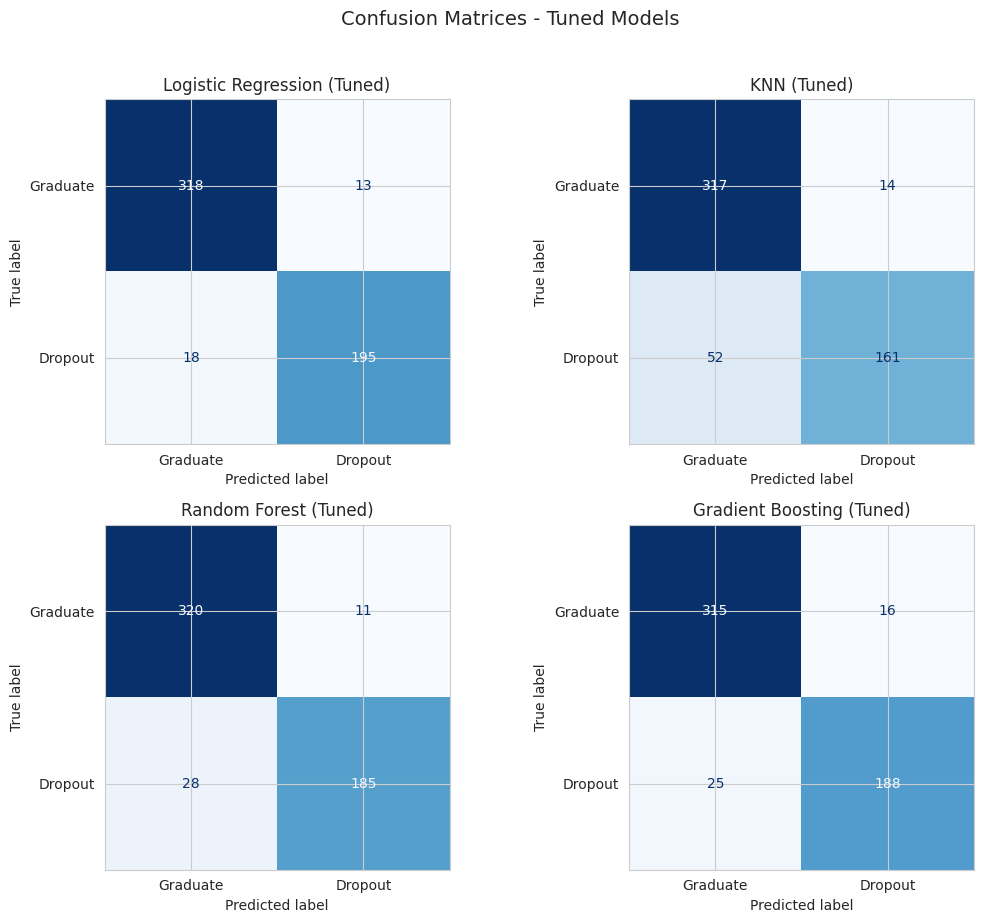

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (name, model) in zip(axes.flat, fitted_models.items()):
    y_pred = model.predict(X_val)
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred, display_labels=["Graduate", "Dropout"],
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)
plt.suptitle("Confusion Matrices - Tuned Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("diagnostic_confusion_matrices_tuned.png", dpi=150)
plt.show()


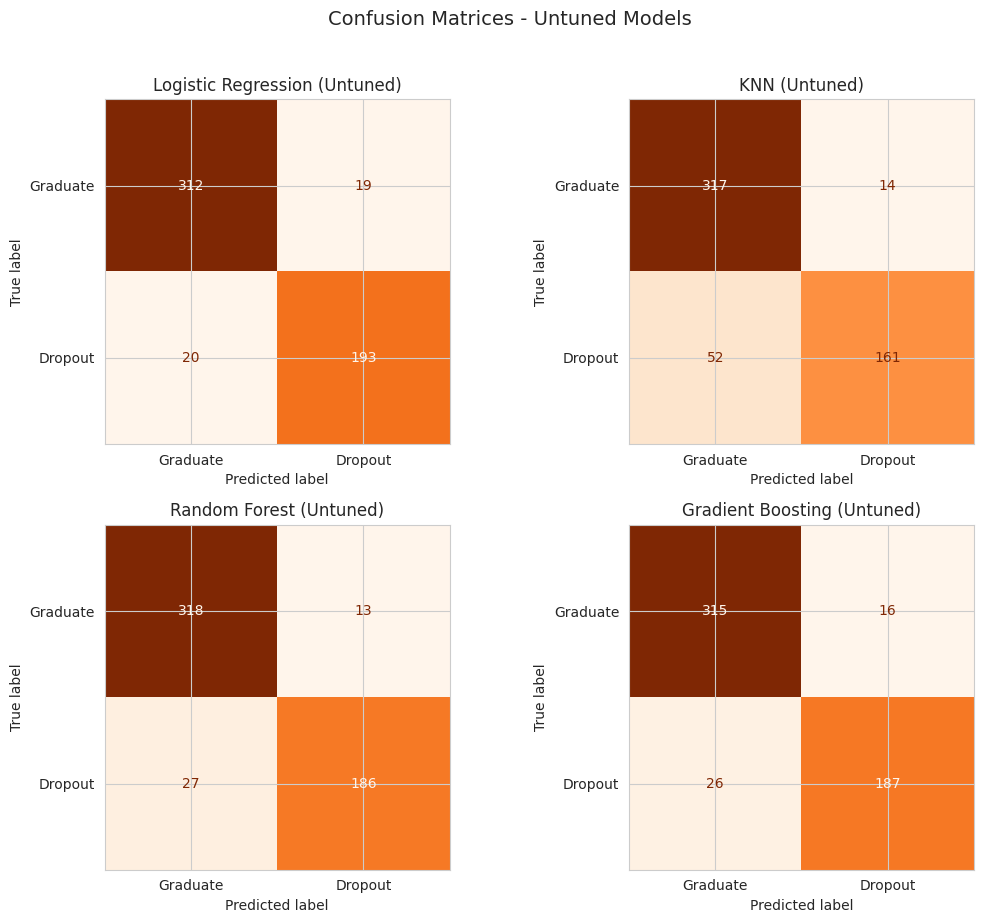

In [33]:
# Untuned versions shown alongside the tuned ones so the effect of tuning on
# error PATTERNS (not just the summary metrics) is visible directly.
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (name, model) in zip(axes.flat, fitted_models_untuned.items()):
    y_pred = model.predict(X_val)
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred, display_labels=["Graduate", "Dropout"],
        ax=ax, cmap="Oranges", colorbar=False
    )
    ax.set_title(name)
plt.suptitle("Confusion Matrices - Untuned Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("diagnostic_confusion_matrices_untuned.png", dpi=150)
plt.show()


### ROC Curves

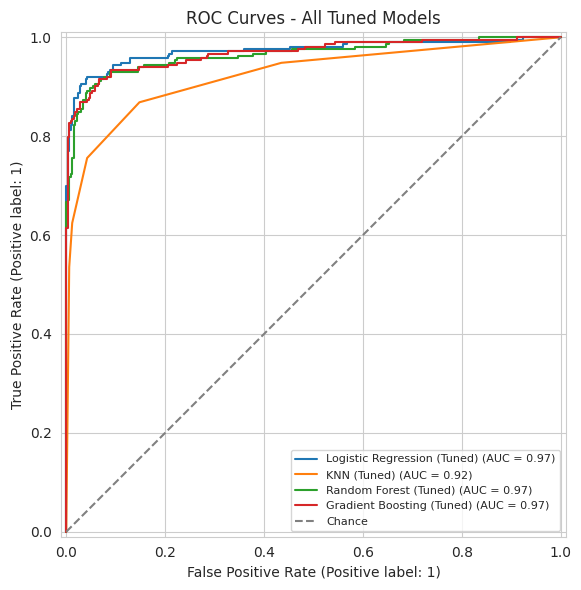

In [34]:
# Overlaying all models on one plot makes the (fairly small) ROC-AUC
# differences between them visible — a table of numbers alone doesn't
# communicate this well.
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curves - All Tuned Models")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("diagnostic_roc_curves_tuned.png", dpi=150)
plt.show()


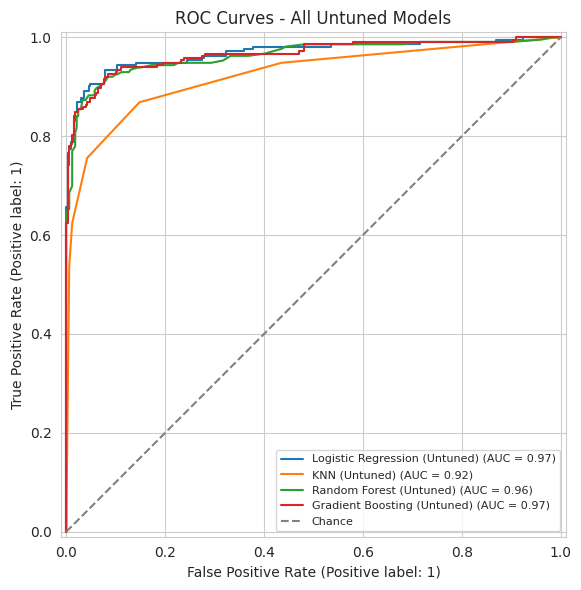

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in fitted_models_untuned.items():
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curves - All Untuned Models")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("diagnostic_roc_curves_untuned.png", dpi=150)
plt.show()


### Bar Charts

In [36]:
# Row order chosen so Untuned/Tuned pairs sit next to each other per model,
# making the effect of tuning visually easy to compare in the chart below.
comparison_plot = validation_comparison_df.loc[['Baseline (Majority Class)',
                                      'Logistic Regression (Untuned)', 'Logistic Regression (Tuned)',
                                      'KNN (Untuned)', 'KNN (Tuned)',
                                      'Random Forest (Untuned)', 'Random Forest (Tuned)',
                                      'Gradient Boosting (Untuned)', 'Gradient Boosting (Tuned)']]


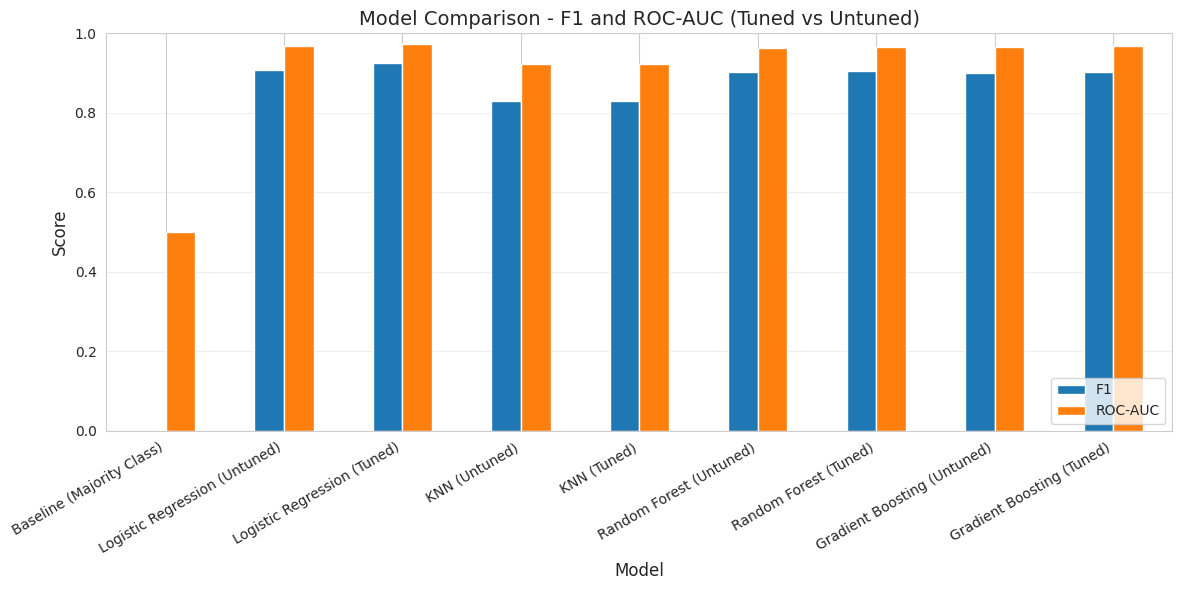

Saved: diagnostic_comparison_chart.png


In [37]:
# Section 8 asks for multi-criteria comparison, not just the top metric — this
# chart pairs F1 (primary metric, given imbalance) with ROC-AUC (threshold-
# independent) so a near-tie on one metric can be checked against the other.
plt.figure(figsize=(12, 6))
comparison_plot[["F1", "ROC-AUC"]].plot(kind="bar", ax=plt.gca())
plt.title("Model Comparison - F1 and ROC-AUC (Tuned vs Untuned)", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("diagnostic_comparison_chart.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: diagnostic_comparison_chart.png")


## Step 20 — Feature Importance / Interpretation (DW-10)

Logistic Regression coefficients are SIGNED (direction + strength); Random
Forest and Gradient Boosting importances are UNSIGNED (strength only, no
direction). Comparing what each model highlights is itself useful evidence
for the report — do the linear and nonlinear models agree on what matters?


### Logistic Regression

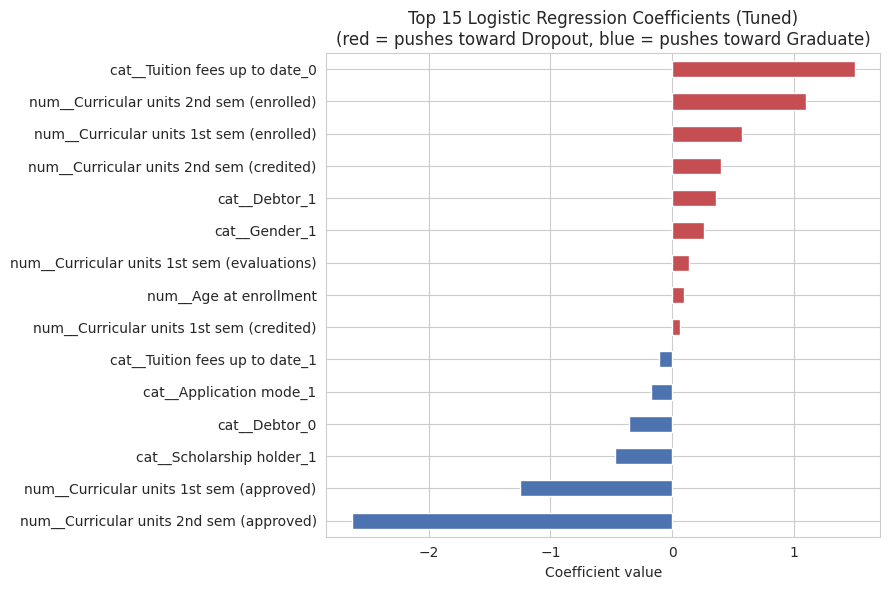

Saved: figures/interpretation_lr_coefficients_tuned.png


In [38]:
lr_model = fitted_models["Logistic Regression (Tuned)"]
# Column order/names change after ColumnTransformer + OneHotEncoder, so feature
# names must be pulled from the fitted preprocessor itself — using the original
# DataFrame's column names here would silently mislabel every coefficient below.
feature_names = lr_model.named_steps["preprocessor"].get_feature_names_out()

# Sorted by absolute value: sign tells direction (toward Dropout=1 or
# Graduate=0), magnitude tells strength — sorting by |coefficient| surfaces the
# most influential features regardless of direction.
lr_coefs = pd.Series(
    lr_model.named_steps["classifier"].coef_[0],
    index=feature_names
).sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 6))
top_lr = lr_coefs.head(15).sort_values()
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_lr]
top_lr.plot(kind="barh", color=colors)
plt.title("Top 15 Logistic Regression Coefficients (Tuned)\n(red = pushes toward Dropout, blue = pushes toward Graduate)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.savefig("figures/interpretation_lr_coefficients_tuned.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/interpretation_lr_coefficients_tuned.png")


### Random Forest

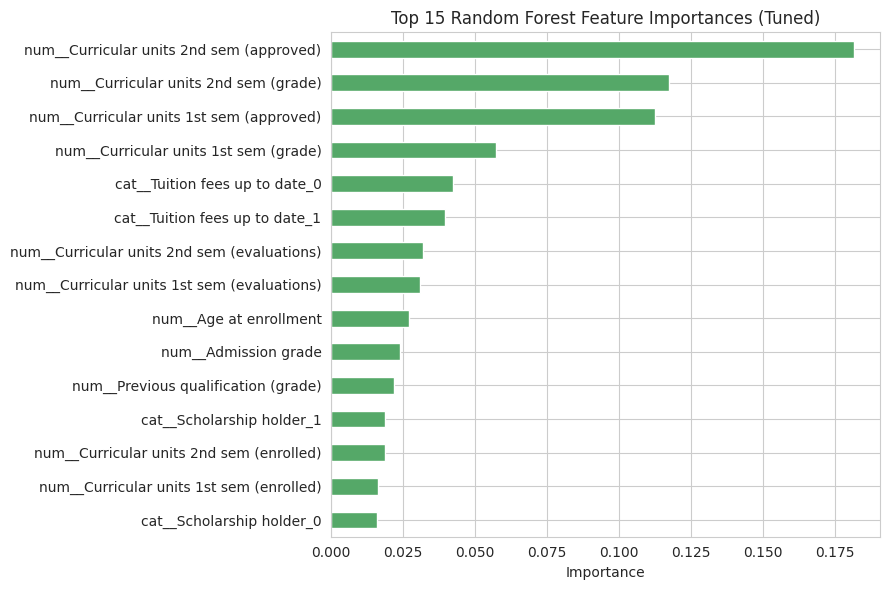

Saved: figures/interpretation_rf_importances_tuned.png


In [39]:
rf_model = fitted_models["Random Forest (Tuned)"]
rf_importances = pd.Series(
    rf_model.named_steps["classifier"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
rf_importances.head(15).sort_values().plot(kind="barh", color="#55A868")
plt.title("Top 15 Random Forest Feature Importances (Tuned)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("figures/interpretation_rf_importances_tuned.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/interpretation_rf_importances_tuned.png")


### Gradient Boosting

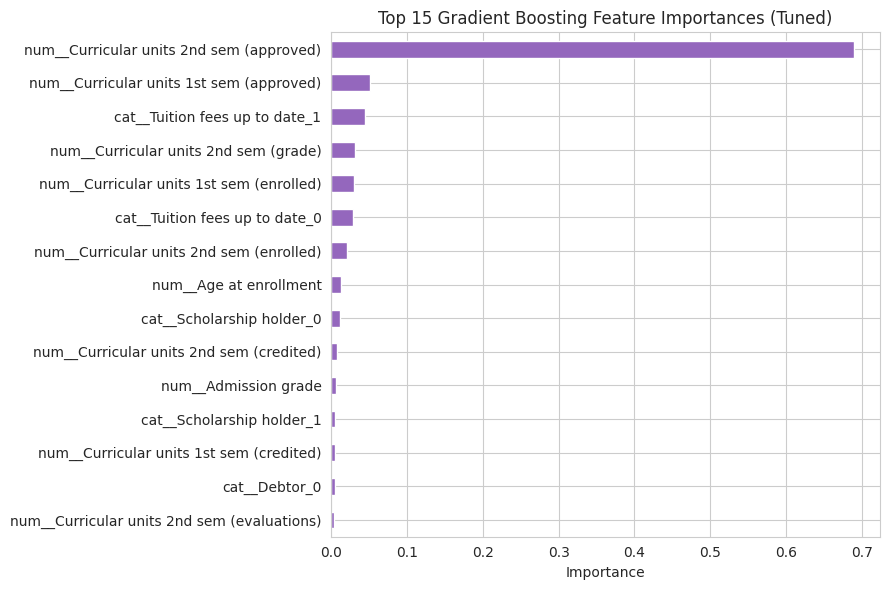

Saved: figures/interpretation_gb_importances_tuned.png


In [40]:
gb_model = fitted_models["Gradient Boosting (Tuned)"]
gb_importances = pd.Series(
    gb_model.named_steps["classifier"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
gb_importances.head(15).sort_values().plot(kind="barh", color="#9467BD")
plt.title("Top 15 Gradient Boosting Feature Importances (Tuned)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("figures/interpretation_gb_importances_tuned.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/interpretation_gb_importances_tuned.png")


## Step 21 — Error Analysis (Section 7 classification requirement)

### Selecting the Final Model

The final model is selected **once using validation-set F1**. Hyperparameters were tuned only with 5-fold cross-validation on the training set.

After the validation winner is frozen, the **15% test set is opened exactly once** for final reporting. No parameter or model choice is changed after seeing the test result.


### Threshold Sensitivity

Default classification threshold is 0.5 — arbitrary for this use case. An
institution would rather over-flag (more false positives — cheap: an extra
advising call) than under-flag (a false negative — a student drops out
unnoticed). This plot shows that tradeoff so a threshold can be chosen
deliberately rather than left at the default.


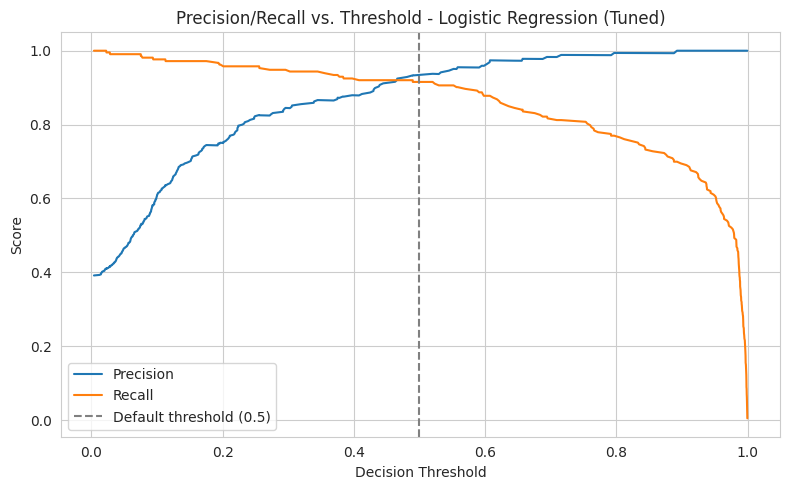

Saved: error_analysis_threshold.png


In [41]:
precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba_best)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title(f"Precision/Recall vs. Threshold - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig("error_analysis_threshold.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: error_analysis_threshold.png")


## Step 22 — Cross-Validation Uncertainty (Section 8 "Uncertainty")

`GridSearchCV` already used cross-validation internally to pick hyperparameters,
but doesn't expose the per-fold spread in an easily reportable way — this makes
it explicit, so the final metric isn't implied to be an exact point estimate.


In [42]:
cv_scores = cross_val_score(
    best_model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1
)
print(f"\n{best_model_name} - 5-fold CV F1: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print(f"Individual fold scores: {np.round(cv_scores, 3)}")



Logistic Regression (Tuned) - 5-fold CV F1: 0.869 +/- 0.025
Individual fold scores: [0.859 0.863 0.911 0.835 0.878]


## Step 23 — Save Final Model (Section 11 "Artifacts", FR-5 reproducibility)

Saves the selected model and the comparison table as files, so reported
numbers are regenerable without re-running the entire training process.


## Final Submission Artifacts

Run the next cell after final test evaluation to save the selected model and required CSV artifacts. Candidate model comparison is based on the validation set; the test set is used only for the selected final model.

## Step 23 — Final Test Evaluation

The test set is opened only after model selection and development diagnostics. The selected model is evaluated on the untouched test set for the final reported evidence.


FINAL TEST EVALUATION - Logistic Regression (Tuned)
Confusion Matrix:
[[316  16]
 [ 32 181]]

Classification Report:
              precision    recall  f1-score   support

    Graduate       0.91      0.95      0.93       332
     Dropout       0.92      0.85      0.88       213

    accuracy                           0.91       545
   macro avg       0.91      0.90      0.91       545
weighted avg       0.91      0.91      0.91       545


Final Test Metrics:
Accuracy: 0.912
Precision: 0.919
Recall: 0.850
F1: 0.883
ROC-AUC: 0.957


<Figure size 600x500 with 0 Axes>

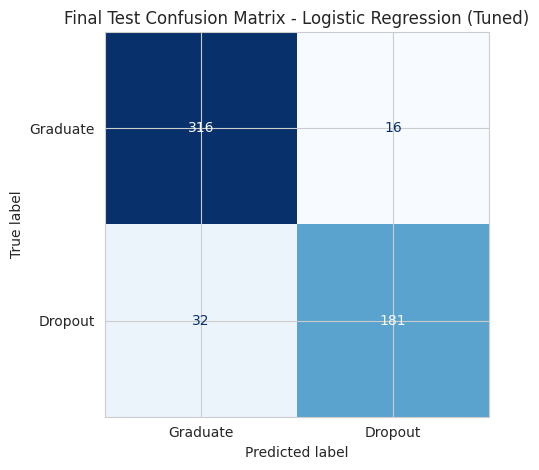

In [43]:
# ========== FINAL TEST EVALUATION ==========
# The test set is used here only for the selected final model.
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

final_test_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "F1": f1_score(y_test, y_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba),
}

print("\n" + "=" * 60)
print(f"FINAL TEST EVALUATION - {best_model_name}")
print("=" * 60)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Graduate", "Dropout"],
    zero_division=0
))
print("\nFinal Test Metrics:")
for metric, value in final_test_metrics.items():
    print(f"{metric}: {value:.3f}")

# Final confusion matrix — this is the only test-set diagnostic plot.
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Graduate", "Dropout"],
    cmap="Blues",
    colorbar=False
)
plt.title(f"Final Test Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("figures/final_test_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [44]:
# =========================
# FINAL ARTIFACTS / SUBMISSION FILES
# =========================

import joblib
import pandas as pd

# 1. Save the selected final pipeline.
# This contains preprocessing + the selected classifier.
joblib.dump(best_model, "final_model.joblib")

# 2. Save model comparison results based on the VALIDATION set.
# Includes baseline, untuned and tuned candidate models.
model_comparison_results = validation_comparison_df.copy()
model_comparison_results.to_csv("model_comparison_results.csv", index=True)

# Backward-compatible copy used by the report/notebook if needed.
validation_comparison_df.to_csv(
    "validation_model_comparison_results.csv",
    index=True
)

# 3. Save final TEST results for the selected model only.
final_test_df = pd.DataFrame([final_test_metrics], index=[best_model_name])
final_test_df.index.name = "Model"
final_test_df.to_csv("final_test_results.csv", index=True)

# 4. Save machine-readable data dictionary.
data_dictionary = pd.DataFrame([
    ["Marital status", "categorical", "Original", "Student's marital status.", "Used"],
    ["Application mode", "categorical", "Original", "Method/channel through which the student applied.", "Used"],
    ["Application order", "numeric", "Original", "Order of application choice.", "Used"],
    ["Course", "categorical", "Original", "Original course/program code; used to create Discipline_Group, then removed.", "Transformed then removed"],
    ["Daytime/evening attendance", "categorical", "Original", "Attendance schedule indicator.", "Used"],
    ["Previous qualification", "categorical", "Original", "Type of qualification obtained before enrollment.", "Used"],
    ["Previous qualification (grade)", "numeric", "Original", "Grade associated with the previous qualification.", "Used"],
    ["Nacionality", "categorical", "Original", "Student nationality.", "Removed: near-constant"],
    ["Mother's qualification", "categorical", "Original", "Mother's highest qualification category.", "Used"],
    ["Father's qualification", "categorical", "Original", "Father's highest qualification category.", "Used"],
    ["Mother's occupation", "categorical", "Original", "Mother's occupation category.", "Used"],
    ["Father's occupation", "categorical", "Original", "Father's occupation category.", "Used"],
    ["Admission grade", "numeric", "Original", "Admission/enrollment grade.", "Used"],
    ["Displaced", "categorical", "Original", "Whether the student is displaced.", "Used"],
    ["Educational special needs", "categorical", "Original", "Indicator for educational special needs.", "Used"],
    ["Debtor", "categorical", "Original", "Whether the student is a debtor.", "Used"],
    ["Tuition fees up to date", "categorical", "Original", "Whether tuition fees are up to date.", "Used"],
    ["Gender", "categorical", "Original", "Student gender.", "Used"],
    ["Scholarship holder", "categorical", "Original", "Whether the student holds a scholarship.", "Used"],
    ["Age at enrollment", "numeric", "Original", "Student age at enrollment.", "Used"],
    ["International", "categorical", "Original", "International student indicator.", "Removed: near-constant"],
    ["Curricular unit 1st sem (credited)", "numeric", "Original", "Credits from first-semester curricular units.", "Used"],
    ["Curricular unit 1st sem (enrolled)", "numeric", "Original", "Enrolled curricular units in first semester.", "Used"],
    ["Curricular unit 1st sem (evaluations)", "numeric", "Original", "Evaluations in first semester.", "Used"],
    ["Curricular unit 1st sem (approved)", "numeric", "Original", "Approved curricular units in first semester.", "Used"],
    ["Curricular unit 1st sem (grade)", "numeric", "Original", "First-semester curricular unit grade.", "Used"],
    ["Curricular unit 1st sem (without evaluations)", "numeric", "Original", "First-semester curricular units without evaluations.", "Used"],
    ["Curricular unit 2nd sem (credited)", "numeric", "Original", "Credits from second-semester curricular units.", "Used"],
    ["Curricular unit 2nd sem (enrolled)", "numeric", "Original", "Enrolled curricular units in second semester.", "Used"],
    ["Curricular unit 2nd sem (evaluations)", "numeric", "Original", "Evaluations in second semester.", "Used"],
    ["Curricular unit 2nd sem (approved)", "numeric", "Original", "Approved curricular units in second semester.", "Used"],
    ["Curricular unit 2nd sem (grade)", "numeric", "Original", "Second-semester curricular unit grade.", "Used"],
    ["Curricular unit 2nd sem (without evaluations)", "numeric", "Original", "Second-semester curricular units without evaluations.", "Used"],
    ["Unemployment rate", "numeric", "Original", "Macroeconomic unemployment rate.", "Removed"],
    ["Inflation rate", "numeric", "Original", "Macroeconomic inflation rate.", "Removed"],
    ["GDP", "numeric", "Original", "Gross domestic product indicator.", "Removed"],
    ["Enrolled", "categorical", "Original", "Enrollment-status category; excluded to avoid target leakage.", "Removed"],
    ["Discipline_Group", "categorical", "Engineered", "Grouped discipline/category derived from Course.", "Used"],
    ["Target", "binary", "Engineered", "Dropout=1 and Graduate=0; Enrolled rows are excluded.", "Target"]
], columns=["Variable", "Type", "Origin", "Description", "Model Status"])

data_dictionary.to_csv("data_dictionary.csv", index=False)

print("Saved:")
print(" - final_model.joblib")
print(" - data_dictionary.csv")
print(" - model_comparison_results.csv")
print(" - final_test_results.csv")
print(" - validation_model_comparison_results.csv")


Saved:
 - final_model.joblib
 - data_dictionary.csv
 - model_comparison_results.csv
 - final_test_results.csv
 - validation_model_comparison_results.csv
